This code aims at predicting the number of heavy atoms in the structure using just one or two peak intensity ratios on a radial distribution function calculated as RDF(r) = G(r)*r + 4πρ0 * r^2. The same dataset of Th cluster structures is used for this calculation.

In [12]:
import os
import matplotlib.pyplot as plt
import glob
import pandas as pd
import numpy as np
from numpy import trapz

Let's look at the distribution of clusters that we have.

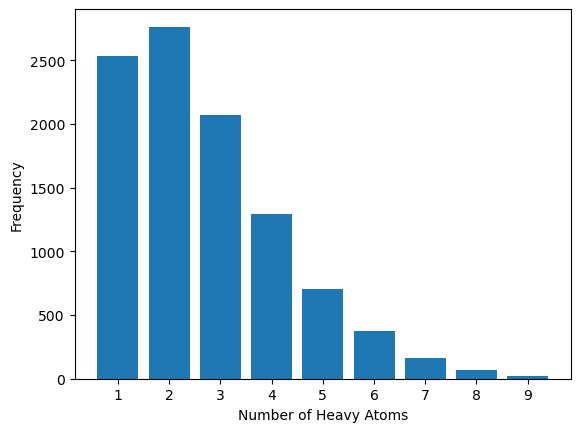

In [13]:
os.chdir('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/th_clusters/test_th_groups')

def read_txt_file(filename):
    with open(filename, 'r') as file:
        lines = file.readlines()
    return [int(line.strip()) for line in lines]

def count_occurrences(numbers):
    count_dict = {str(i): 0 for i in range(1, 10)}
    for number in numbers:
        count_dict[str(number)] += 1
    return count_dict

def plot_bar_chart(count_dict):
    numbers = list(count_dict.keys())
    counts = list(count_dict.values())

    plt.bar(numbers, counts)
    plt.xlabel('Number of Heavy Atoms')
    plt.ylabel('Frequency')
    plt.show()

filename = 'labels.txt'
numbers = read_txt_file(filename)
count_dict = count_occurrences(numbers)
plot_bar_chart(count_dict)

Let's start with preparing the data. We need to calculate the G(r)*r first from the G(r) files

(-10.0, 60.0)

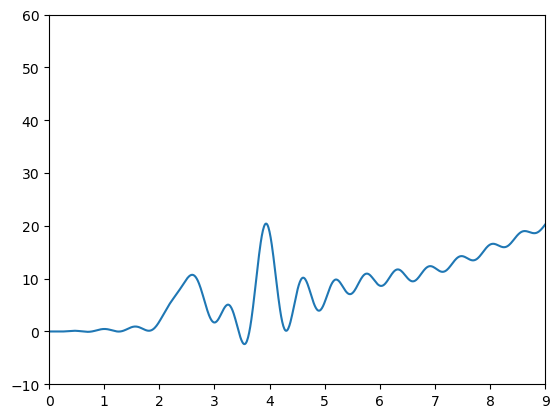

In [14]:
files_calc = glob.glob('*.dat')
for i, f in zip(range(1,10000),files_calc):
    data = pd.read_csv(f, skiprows=1, delim_whitespace=True, index_col=False)
    data.columns = ['a','b']
    df = pd.DataFrame(data)
    df['c'] = df.b * df.a + 4 * np.pi * 4 / 175.33 * df.a * df.a
    df.to_csv(f.replace('.dat','_radial.txt'),index_label=False, sep=' ', header=None, index=False)

fig, ax = plt.subplots()
ax.plot(df.a, df.c)
ax.set_xlim(0,9)
ax.set_ylim(-10, 60)

In [15]:
files_radial = glob.glob('*_radial.txt')

with open('peak_int.txt', 'w') as peak_int:
    peak_int.write('atoms peak1 peak2 peak3 2/1-ratio 2/3-ratio \n')
    for i, f in zip(range(1,10000),files_radial):
        data = pd.read_csv(f, delim_whitespace=True, index_col=False)
        data.columns = ['a','b','c']
        df = pd.DataFrame(data)

        peak1 = df.loc[(df['a'] >= 2.0) & (df['a'] <= 3.0)]
        peak2 = df.loc[(df['a'] >= 3.5) & (df['a'] <= 4.2)]
        peak3 = df.loc[(df['a'] >= 6.0) & (df['a'] <= 7.0)]
        area1 = trapz(peak1.c, peak1.a)
        area2 = trapz(peak2.c, peak2.a)
        area3 = trapz(peak3.c, peak3.a)

        peak_int.write(f[0])
        peak_int.write(' ')
        peak_int.write(str(area1))
        peak_int.write(' ')
        peak_int.write(str(area2))
        peak_int.write(' ')
        peak_int.write(str(area3))
        peak_int.write(' ')
        peak_int.write(str(area2/area1))
        peak_int.write(' ')
        peak_int.write(str(area2/area3))

        peak_int.write('\n')    

Let's visualize our data clusters

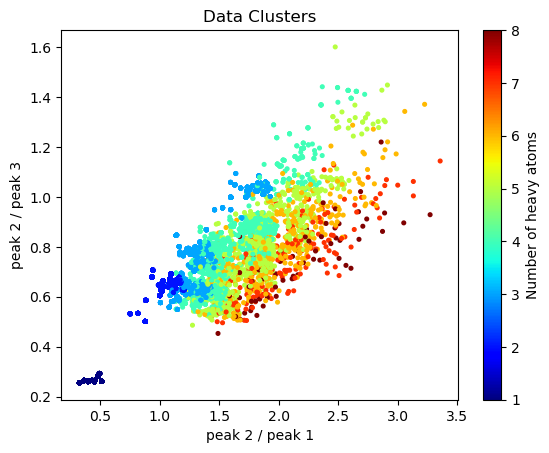

In [32]:
ratio_data = pd.read_csv('peak_int.txt', skiprows=1, delim_whitespace=True, index_col=False)
ratio_data.columns = ['Number_of_heavy_atoms','peak 1','peak 2','peak 3','Intensity_Ratio1','Intensity_Ratio2']

ratio_data = ratio_data[ratio_data.iloc[:, 0] != 9]

plt.scatter(ratio_data['Intensity_Ratio1'], ratio_data['Intensity_Ratio2'], c=ratio_data['Number_of_heavy_atoms'], cmap='jet', s=7, alpha=1)
plt.xlabel('peak 2 / peak 1')
plt.ylabel('peak 2 / peak 3')
plt.title('Data Clusters')
plt.colorbar(label='Number of heavy atoms')
plt.show()

Let's try the Gradient Boosting Machine regression model

Mean Absolute Error (MAE): 0.11
Mean Squared Error (MSE): 0.11
Root Mean Squared Error (RMSE): 0.33
R-squared (R2): 0.95


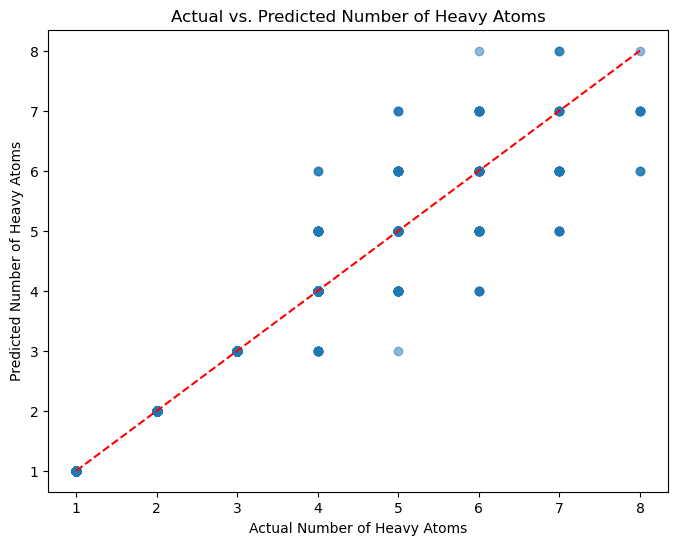

Confusion Matrix:
[[499   0   0   0   0   0   0   0]
 [  0 564   0   0   0   0   0   0]
 [  0   0 418   0   0   0   0   0]
 [  0   0  11 213  23   3   0   0]
 [  0   0   1  28  87  21   4   0]
 [  0   0   0   5  29  27  15   1]
 [  0   0   0   0   7  16   8   3]
 [  0   0   0   0   0   3   8   1]]
Percentage of Correct Predictions: 91.08%


In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix

X = ratio_data[['Intensity_Ratio1', 'Intensity_Ratio2']].values
y = ratio_data['Number_of_heavy_atoms'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the Gradient Boosting Regressor
gbm = GradientBoostingRegressor(n_estimators=10000, learning_rate=0.1, max_depth=10)

# Train the model on the training data
gbm.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gbm.predict(X_test)
y_pred_rounded = np.round(y_pred)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r_squared = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f"R-squared (R2): {r_squared:.2f}")

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rounded, alpha=0.5)

# Add labels and title
plt.xlabel('Actual Number of Heavy Atoms')
plt.ylabel('Predicted Number of Heavy Atoms')
plt.title('Actual vs. Predicted Number of Heavy Atoms')

# Add a diagonal line (y=x) to show ideal predictions
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')

# Show the plot
plt.show()

conf_matrix = confusion_matrix(y_test, y_pred_rounded)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate the percentage of correct predictions within the tolerance
correct_predictions = np.abs(y_test - y_pred_rounded) <= 0.5
percentage_correct = (np.sum(correct_predictions) / len(y_test)) * 100

print(f"Percentage of Correct Predictions: {percentage_correct:.2f}%")



Let's try Poisson regression.

In [34]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Assuming you have a DataFrame 'data' with columns 'Intensity_Ratio1', 'Intensity_Ratio2', and 'Number_of_heavy_atoms'
X = ratio_data[['Intensity_Ratio1', 'Intensity_Ratio2']].values
y = ratio_data['Number_of_heavy_atoms'].values

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Poisson regression model on the training data
poisson_model = sm.GLM(y_train, sm.add_constant(X_train), family=sm.families.Poisson())
poisson_results = poisson_model.fit()

# Get predicted number of atoms on the test set
y_pred_poisson = poisson_results.predict(sm.add_constant(X_test))

# Round the predictions to the nearest natural number
y_pred_rounded = np.round(y_pred_poisson)

# Now 'y_pred_rounded' contains the rounded predicted number of atoms for the test set


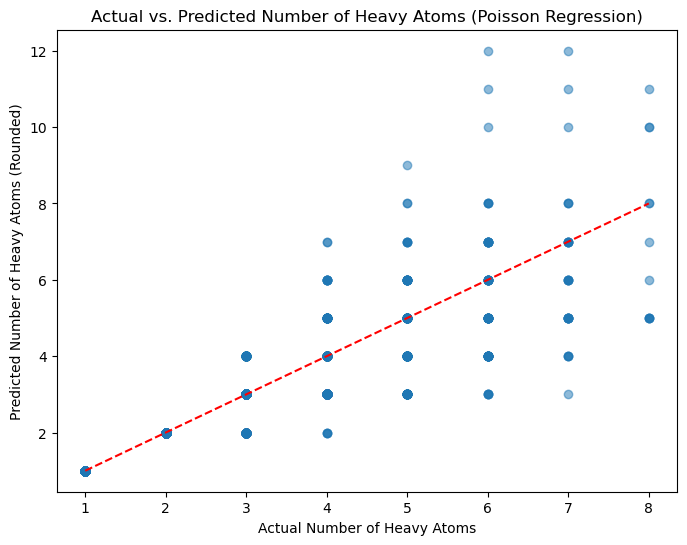

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have the actual values 'y_test' and the rounded predicted values 'y_pred_rounded'

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rounded, alpha=0.5)

# Add labels and title
plt.xlabel('Actual Number of Heavy Atoms')
plt.ylabel('Predicted Number of Heavy Atoms (Rounded)')
plt.title('Actual vs. Predicted Number of Heavy Atoms (Poisson Regression)')

# Add a diagonal line (y=x) to show ideal predictions
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')

# Show the plot
plt.show()

Let's try random forest

Mean Absolute Error (MAE): 0.10
Mean Squared Error (MSE): 0.13
Root Mean Squared Error (RMSE): 0.35
R-squared (R2): 0.95


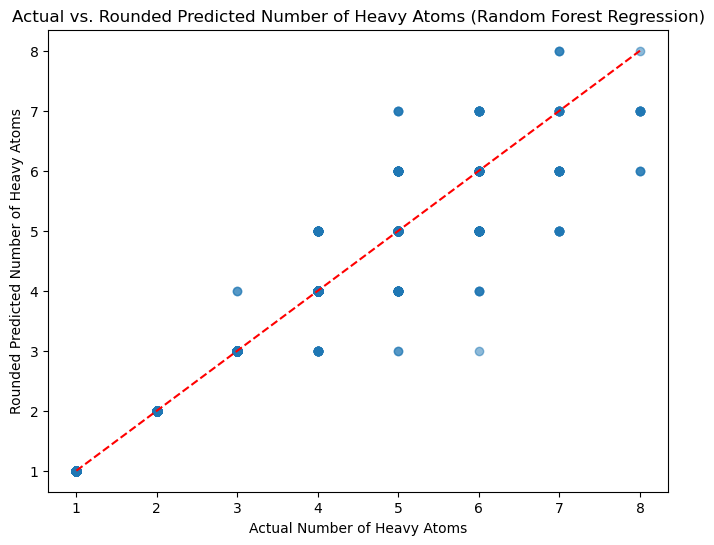

Confusion Matrix:
[[499   0   0   0   0   0   0   0]
 [  0 564   0   0   0   0   0   0]
 [  0   0 416   2   0   0   0   0]
 [  0   0  13 212  25   0   0   0]
 [  0   0   2  23  90  22   4   0]
 [  0   0   1   4  34  25  13   0]
 [  0   0   0   0   8  14   9   3]
 [  0   0   0   0   0   3   8   1]]
Percentage of Correct Predictions: 91.03%


In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import matplotlib.pyplot as plt

# Assuming you have a DataFrame 'data' with columns 'Intensity_Ratio1', 'Intensity_Ratio2', and 'Number_of_heavy_atoms'
X = ratio_data[['Intensity_Ratio1', 'Intensity_Ratio2']].values
y = ratio_data['Number_of_heavy_atoms'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=1000, max_depth=40, random_state=42)

# Train the model on the training data
rf_regressor.fit(X_train, y_train)

# Get predictions on the test set
y_pred = rf_regressor.predict(X_test)

# Round the predicted values to the closest natural number
y_pred_rounded = np.round(y_pred)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_rounded)
mse = mean_squared_error(y_test, y_pred_rounded)
rmse = np.sqrt(mse)
r_squared = r2_score(y_test, y_pred_rounded)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r_squared:.2f}")

# Create a scatter plot to visualize the comparison between actual and rounded predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rounded, alpha=0.5)

# Add labels and title
plt.xlabel('Actual Number of Heavy Atoms')
plt.ylabel('Rounded Predicted Number of Heavy Atoms')
plt.title('Actual vs. Rounded Predicted Number of Heavy Atoms (Random Forest Regression)')

# Add a diagonal line (y=x) to show ideal predictions
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')

# Show the plot
plt.show()

conf_matrix = confusion_matrix(y_test, y_pred_rounded)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate the percentage of correct predictions within the tolerance
correct_predictions = np.abs(y_test - y_pred_rounded) <= 0.5
percentage_correct = (np.sum(correct_predictions) / len(y_test)) * 100

print(f"Percentage of Correct Predictions: {percentage_correct:.2f}%")


Let's try the Bayesian regression

Mean Absolute Error (MAE): 0.41
Mean Squared Error (MSE): 0.33
Root Mean Squared Error (RMSE): 0.57
R-squared (R2): 0.86


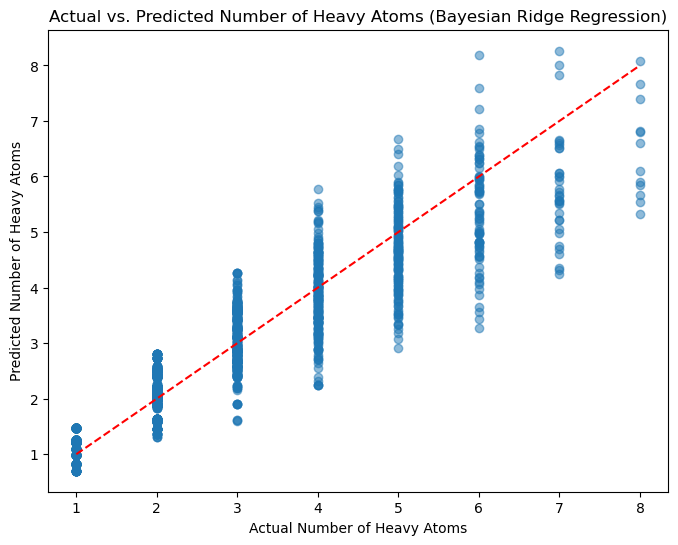

Confusion Matrix:
[[499   0   0   0   0   0   0   0]
 [ 38 412 114   0   0   0   0   0]
 [  0  41 273 104   0   0   0   0]
 [  0   6  72 122  48   2   0   0]
 [  0   0   9  47  64  20   1   0]
 [  0   0   2  10  30  27   6   2]
 [  0   0   0   3   8  14   6   3]
 [  0   0   0   0   1   5   4   2]]
Percentage of Correct Predictions: 70.43%


In [39]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import matplotlib.pyplot as plt

# Assuming you have a DataFrame 'data' with columns 'Intensity_Ratio1', 'Intensity_Ratio2', and 'Number_of_heavy_atoms'
X = ratio_data[['Intensity_Ratio1', 'Intensity_Ratio2']].values
y = ratio_data['Number_of_heavy_atoms'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the Bayesian Ridge Regressor
bayesian_regressor = BayesianRidge(alpha_1=1e-6, alpha_2=1e-6, lambda_1=1e-6, lambda_2=1e-6, n_iter=600)

# Train the model on the training data
bayesian_regressor.fit(X_train, y_train)

# Get predictions on the test set
y_pred = bayesian_regressor.predict(X_test)
y_pred_rounded = np.round(y_pred)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r_squared = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r_squared:.2f}")

# Create a scatter plot to visualize the comparison between actual and predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Add labels and title
plt.xlabel('Actual Number of Heavy Atoms')
plt.ylabel('Predicted Number of Heavy Atoms')
plt.title('Actual vs. Predicted Number of Heavy Atoms (Bayesian Ridge Regression)')

# Add a diagonal line (y=x) to show ideal predictions
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')

# Show the plot
plt.show()


conf_matrix = confusion_matrix(y_test, y_pred_rounded)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate the percentage of correct predictions within the tolerance
correct_predictions = np.abs(y_test - y_pred_rounded) <= 0.5
percentage_correct = (np.sum(correct_predictions) / len(y_test)) * 100

print(f"Percentage of Correct Predictions: {percentage_correct:.2f}%")


Let's try a simple neural network

Epoch 1/20
32/32 [==============================] - 0s 3ms/step - loss: 7.2548 - accuracy: 0.1135 - val_loss: 5.1625 - val_accuracy: 0.2544
Epoch 2/20
32/32 [==============================] - 0s 1ms/step - loss: 3.3139 - accuracy: 0.2553 - val_loss: 1.7963 - val_accuracy: 0.2544
Epoch 3/20
32/32 [==============================] - 0s 1ms/step - loss: 1.4539 - accuracy: 0.2553 - val_loss: 1.0371 - val_accuracy: 0.2544
Epoch 4/20
32/32 [==============================] - 0s 958us/step - loss: 0.8381 - accuracy: 0.2553 - val_loss: 0.5892 - val_accuracy: 0.2544
Epoch 5/20
32/32 [==============================] - 0s 945us/step - loss: 0.4895 - accuracy: 0.2553 - val_loss: 0.3957 - val_accuracy: 0.2544
Epoch 6/20
32/32 [==============================] - 0s 981us/step - loss: 0.3533 - accuracy: 0.2553 - val_loss: 0.3348 - val_accuracy: 0.2544
Epoch 7/20
32/32 [==============================] - 0s 1ms/step - loss: 0.3080 - accuracy: 0.2553 - val_loss: 0.3196 - val_accuracy: 0.2544
Epoch 8/20
32/

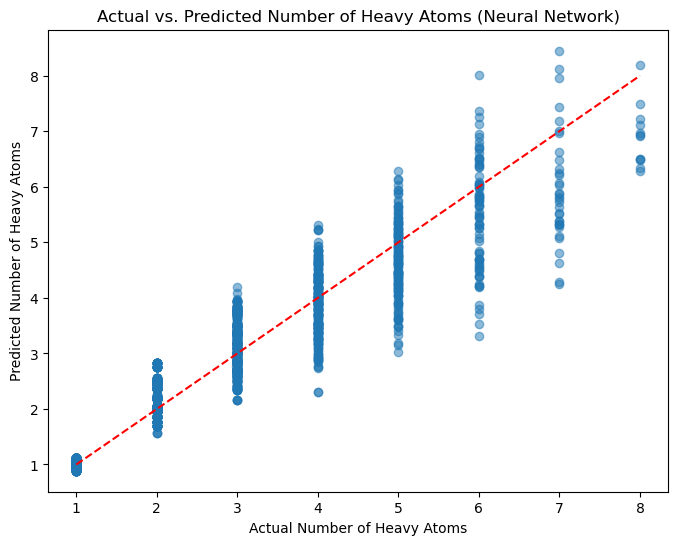

Confusion Matrix:
[[499   0   0   0   0   0   0   0]
 [  0 505  59   0   0   0   0   0]
 [  0  33 290  95   0   0   0   0]
 [  0   2  67 138  43   0   0   0]
 [  0   0   6  54  64  17   0   0]
 [  0   0   1  13  22  27  13   1]
 [  0   0   0   2  10  14   5   3]
 [  0   0   0   0   0   4   7   1]]
Percentage of Correct Predictions: 76.64%
dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


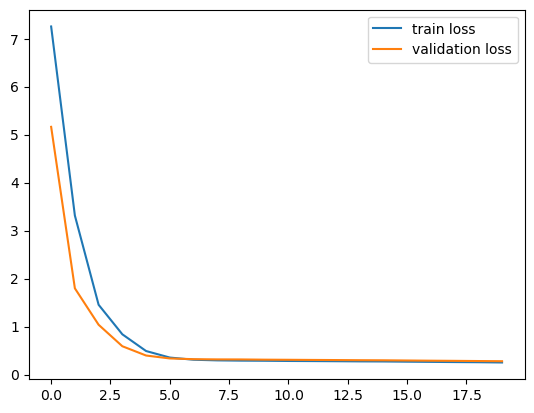

In [47]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import matplotlib.pyplot as plt

# Assuming you have a DataFrame 'data' with columns 'Intensity_Ratio1', 'Intensity_Ratio2', and 'Number_of_heavy_atoms'
X = ratio_data[['Intensity_Ratio1', 'Intensity_Ratio2']].values
y = ratio_data['Number_of_heavy_atoms'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a simple neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

# Train the model on the training data
num_epochs = 20
history = model.fit(X_train_scaled, y_train, batch_size=200, epochs=num_epochs, validation_split=0.2, verbose=1)

# Get predictions on the test set
y_pred = model.predict(X_test_scaled).flatten()
y_pred_rounded = np.round(y_pred)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r_squared = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r_squared:.2f}")

# Create a scatter plot to visualize the comparison between actual and predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Add labels and title
plt.xlabel('Actual Number of Heavy Atoms')
plt.ylabel('Predicted Number of Heavy Atoms')
plt.title('Actual vs. Predicted Number of Heavy Atoms (Neural Network)')

# Add a diagonal line (y=x) to show ideal predictions
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')

# Show the plot
plt.show()

conf_matrix = confusion_matrix(y_test, y_pred_rounded)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate the percentage of correct predictions within the tolerance
correct_predictions = np.abs(y_test - y_pred_rounded) <= 0.5
percentage_correct = (np.sum(correct_predictions) / len(y_test)) * 100

print(f"Percentage of Correct Predictions: {percentage_correct:.2f}%")

print(history.history.keys())
xc         = range(num_epochs)

plt.plot(xc, history.history['loss'], label='train loss')
plt.plot(xc, history.history['val_loss'], label='validation loss')
plt.legend()
